In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/navic_ml_ready.csv"
)

In [8]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/navic_ml_ready.csv"
)

features = [
    'Satellite X Position-7 (m)',
    'Satellite Y Position-7 (m)',
    'Satellite Z Position-7 (m)',

    'Satellite X Velocity-7 (m/s)',
    'Satellite Y Velocity-7 (m/s)',
    'Satellite Z Velocity-7 (m/s)',

    'Azimuth-7 (deg)',
    'Elevation-7 (deg)'
]

target = [
    'Satellite X Position-7 (m)',
    'Satellite Y Position-7 (m)',
    'Satellite Z Position-7 (m)',

    'Azimuth-7 (deg)',
    'Elevation-7 (deg)'
]

X = df[features].values
y = df[target].values

SEQ_LEN = 100

X_seq = []
y_seq = []

for i in range(len(X) - SEQ_LEN):

    X_seq.append(
        X[i:i + SEQ_LEN]
    )

    y_seq.append(
        y[i + SEQ_LEN]
    )

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_seq,
    y_seq,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=1/3,
    random_state=42,
    shuffle=True
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)

np.save("X_val.npy", X_val)
np.save("y_val.npy", y_val)

np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)

print("Data Preparation Complete")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (53438, 100, 8)
Val: (15268, 100, 8)
Test: (7635, 100, 8)
Data Preparation Complete


In [9]:
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")

X_val = np.load("X_val.npy")
y_val = np.load("y_val.npy")

model = Sequential()

model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    LSTM(64)
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dense(
        32,
        activation='relu'
    )
)

model.add(
    Dense(5)
)

optimizer = Adam(
    learning_rate=0.0005
)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_data=(
        X_val,
        y_val
    ),
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

model.save(
    "navic_best_model.keras"
)

print("Model Saved Successfully")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
835/835 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0098 - mae: 0.0553 - val_loss: 5.4390e-04 - val_mae: 0.0200 - learning_rate: 5.0000e-04
Epoch 2/100
835/835 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.0011 - mae: 0.0249 - val_loss: 6.1919e-04 - val_mae: 0.0195 - learning_rate: 5.0000e-04
Epoch 3/100
835/835 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - loss: 5.2503e-04 - mae: 0.0176 - val_loss: 3.9865e-04 - val_mae: 0.0150 - learning_rate: 5.0000e-04
Epoch 4/100
835/835 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 3.6513e-04 - mae: 0.0146 - val_loss: 3.3102e-04 - val_mae: 0.0132 - learning_rate: 5.0000e-04
Epoch 5/100
835/835 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 2.8999e-04 - mae: 0.0129 - val_loss: 2.4668e-04 - val_mae: 0.0126 - learning_rate: 5.0000e-04
Epoch 6/100
835/835 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 2.4063e-04 - mae: 0.0117 - val_loss: 4.1765e-04 - val_mae: 0.0155 - learning_rate: 5.0000e-04
Epoch 7/100
835/835 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 2.0

Loading Model...
Model Loaded Successfully

X_test Shape : (7635, 100, 8)
y_test Shape : (7635, 5)

Generating Predictions...
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

MODEL PERFORMANCE
RMSE                : 0.015602
MAE                 : 0.012494
R² Score            : 0.997819

Axis Wise R²
R² X Position       : 0.996182
R² Y Position       : 0.997344
R² Z Position       : 0.997945
R² Azimuth          : 0.999337
R² Elevation        : 0.998288

Approx Accuracy     : 98.75%

FIRST 20 ACTUAL VALUES
[[7.31394953e-01 9.88449158e-01 8.23827104e-01 1.86045824e-01
  8.34488935e-01]
 [7.06597105e-01 1.81895101e-01 2.39910249e-02 9.81282927e-01
  3.21299801e-02]
 [6.60162664e-01 1.29289124e-01 1.17150956e-02 9.91765025e-01
  1.75234300e-02]
 [1.56598860e-01 7.85751865e-01 4.81513581e-01 5.26008170e-01
  4.84751985e-01]
 [1.29410253e-01 7.53492868e-01 4.58486658e-01 5.48418855e-01
  4.60846227e-01]
 [6.50058742e-01 7.20459039e-01 6.31178823e-01 3.80511129e-01
  6.39948529e-01]
 [5.57927516e-02 6

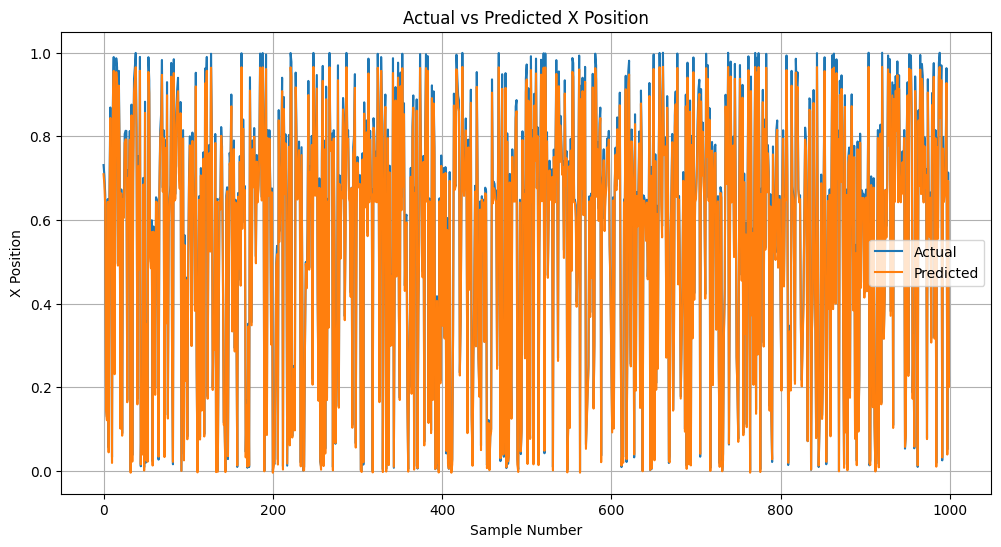

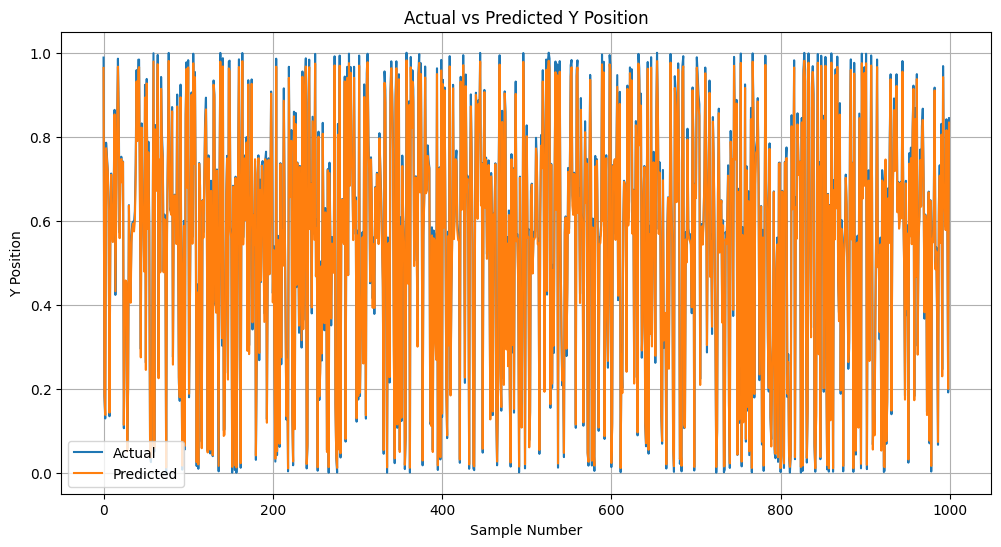

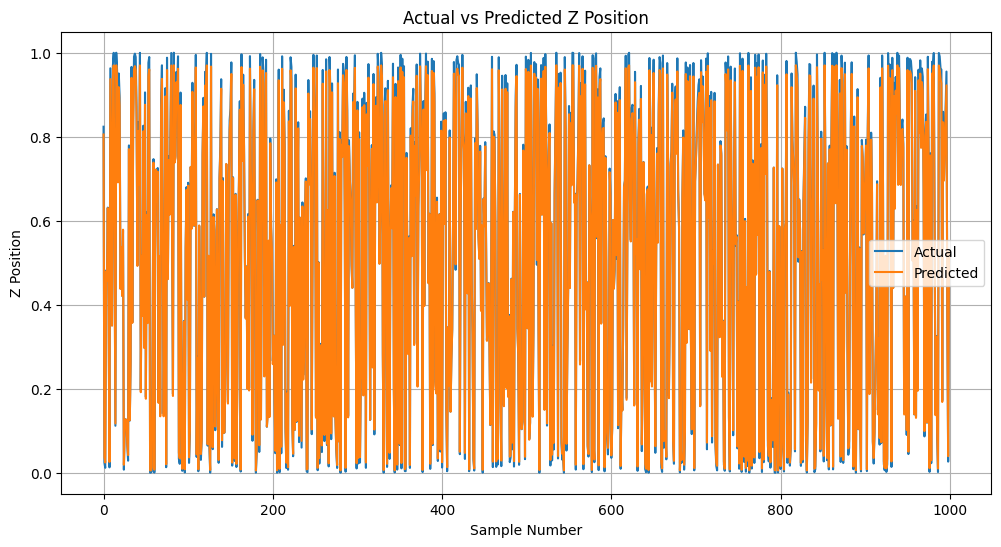

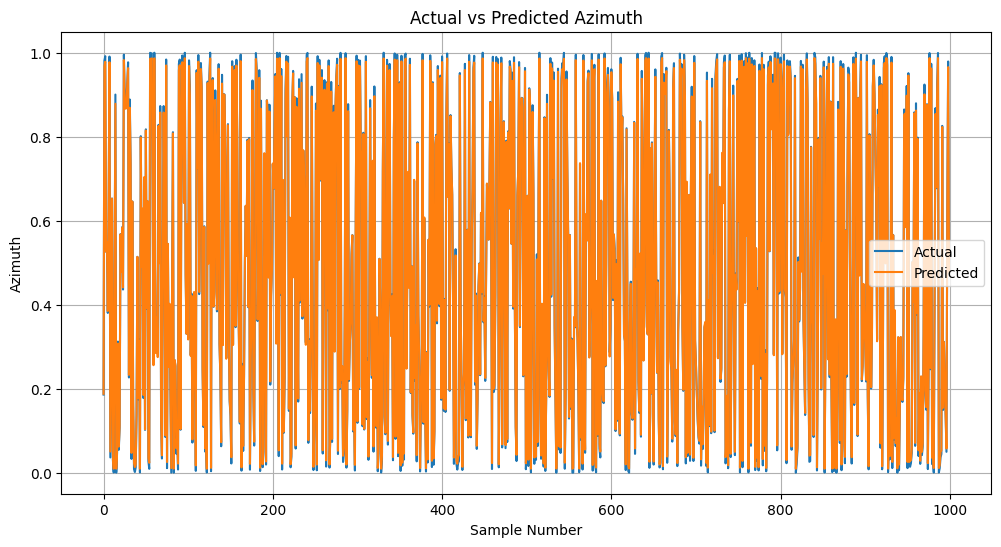

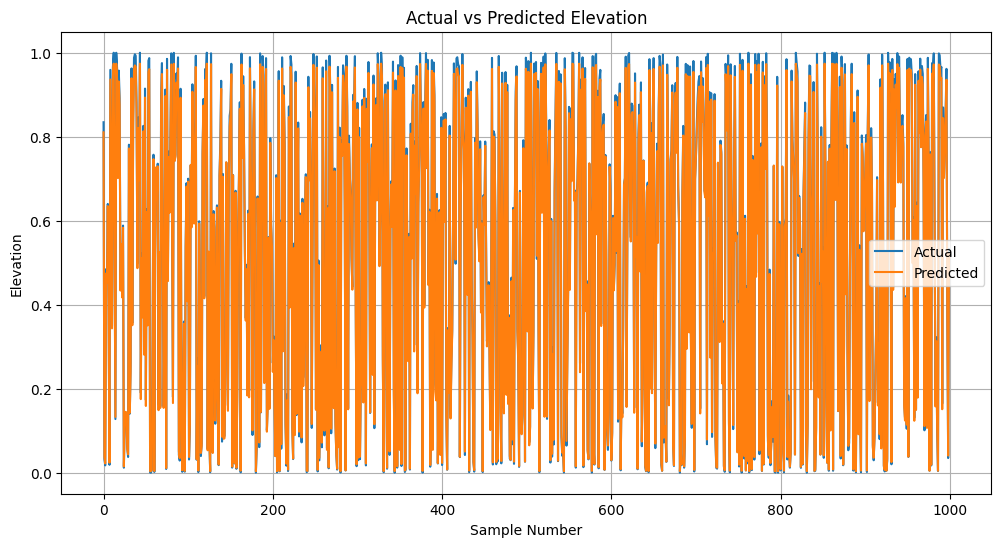

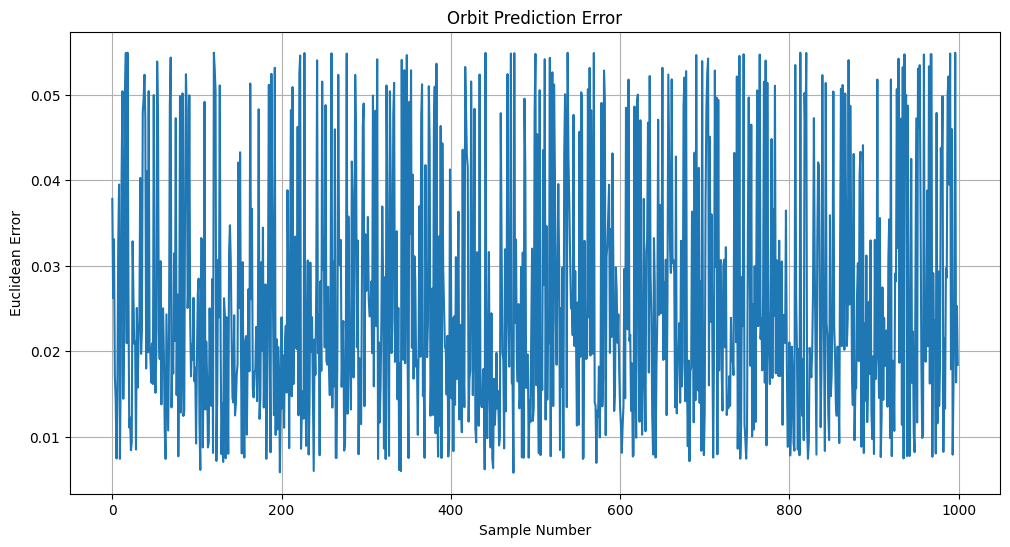

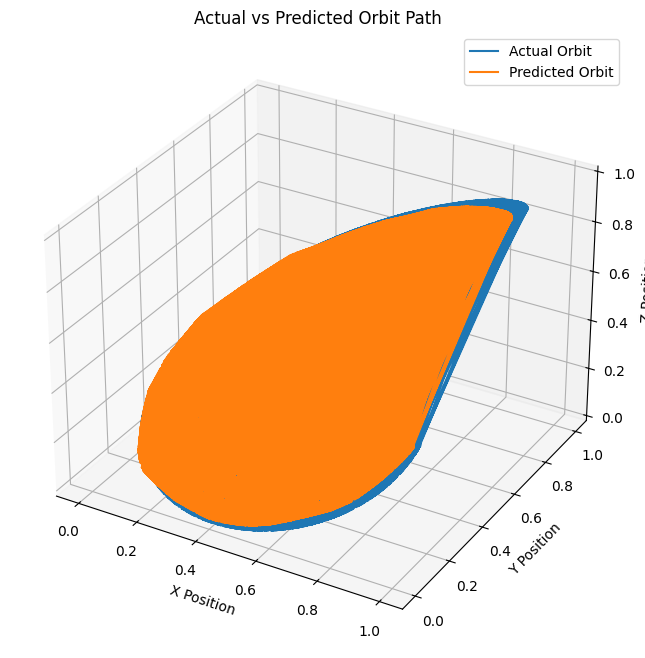


EVALUATION COMPLETE


In [10]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# ==========================================
# LOAD MODEL
# ==========================================

print("Loading Model...")

model = load_model(
    "navic_best_model.keras",
    compile=False
)

print("Model Loaded Successfully")

# ==========================================
# LOAD TEST DATA
# ==========================================

X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

print("\nX_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)

# ==========================================
# GENERATE PREDICTIONS
# ==========================================

print("\nGenerating Predictions...")

predictions = model.predict(X_test)

# ==========================================
# PERFORMANCE METRICS
# ==========================================

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

accuracy = (1 - mae) * 100

# ==========================================
# INDIVIDUAL R² SCORES
# ==========================================

r2_x = r2_score(
    y_test[:,0],
    predictions[:,0]
)

r2_y = r2_score(
    y_test[:,1],
    predictions[:,1]
)

r2_z = r2_score(
    y_test[:,2],
    predictions[:,2]
)

r2_az = r2_score(
    y_test[:,3],
    predictions[:,3]
)

r2_el = r2_score(
    y_test[:,4],
    predictions[:,4]
)

# ==========================================
# PRINT RESULTS
# ==========================================

print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print(f"RMSE                : {rmse:.6f}")
print(f"MAE                 : {mae:.6f}")
print(f"R² Score            : {r2:.6f}")

print("\nAxis Wise R²")

print(f"R² X Position       : {r2_x:.6f}")
print(f"R² Y Position       : {r2_y:.6f}")
print(f"R² Z Position       : {r2_z:.6f}")
print(f"R² Azimuth          : {r2_az:.6f}")
print(f"R² Elevation        : {r2_el:.6f}")

print(f"\nApprox Accuracy     : {accuracy:.2f}%")

# ==========================================
# ACTUAL VS PREDICTED VALUES
# ==========================================

print("\n===================================")
print("FIRST 20 ACTUAL VALUES")
print("===================================")

print(y_test[:20])

print("\n===================================")
print("FIRST 20 PREDICTED VALUES")
print("===================================")

print(predictions[:20])

# ==========================================
# ERROR ANALYSIS
# ==========================================

errors = np.abs(
    y_test - predictions
)

print("\n===================================")
print("AVERAGE FEATURE ERROR")
print("===================================")

print("Average X Error        :", np.mean(errors[:,0]))
print("Average Y Error        :", np.mean(errors[:,1]))
print("Average Z Error        :", np.mean(errors[:,2]))
print("Average Azimuth Error  :", np.mean(errors[:,3]))
print("Average Elevation Error:", np.mean(errors[:,4]))

# ==========================================
# VARIANCE ANALYSIS
# ==========================================

actual_variance = np.var(y_test)
prediction_variance = np.var(predictions)

print("\n===================================")
print("VARIANCE ANALYSIS")
print("===================================")

print("Actual Variance     :", actual_variance)
print("Prediction Variance :", prediction_variance)

# ==========================================
# FEATURE PLOTS
# ==========================================

labels = [
    "X Position",
    "Y Position",
    "Z Position",
    "Azimuth",
    "Elevation"
]

for i in range(5):

    plt.figure(figsize=(12,6))

    plt.plot(
        y_test[:1000,i],
        label="Actual"
    )

    plt.plot(
        predictions[:1000,i],
        label="Predicted"
    )

    plt.title(
        f"Actual vs Predicted {labels[i]}"
    )

    plt.xlabel("Sample Number")
    plt.ylabel(labels[i])

    plt.legend()
    plt.grid(True)

    plt.show()

# ==========================================
# ORBIT ERROR PLOT
# ==========================================

orbit_error = np.sqrt(
    (y_test[:,0] - predictions[:,0])**2 +
    (y_test[:,1] - predictions[:,1])**2 +
    (y_test[:,2] - predictions[:,2])**2
)

plt.figure(figsize=(12,6))

plt.plot(
    orbit_error[:1000]
)

plt.title(
    "Orbit Prediction Error"
)

plt.xlabel("Sample Number")
plt.ylabel("Euclidean Error")

plt.grid(True)

plt.show()

# ==========================================
# 3D ORBIT VISUALIZATION
# ==========================================

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.plot(
    y_test[:2000,0],
    y_test[:2000,1],
    y_test[:2000,2],
    label='Actual Orbit'
)

ax.plot(
    predictions[:2000,0],
    predictions[:2000,1],
    predictions[:2000,2],
    label='Predicted Orbit'
)

ax.set_title(
    "Actual vs Predicted Orbit Path"
)

ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.set_zlabel("Z Position")

ax.legend()

plt.show()

# ==========================================
# COMPLETED
# ==========================================

print("\n===================================")
print("EVALUATION COMPLETE")
print("===================================")